In [1]:
import pandas as pd
import numpy as np


In [10]:
try:
    trader_data = pd.read_csv('historical_data.csv')
    sentiment_data = pd.read_csv('fear_greed_index.csv')

    print("Datasets loaded successfully.")
except FileNotFoundError as e:
    print(f"Error: {e}. Please ensure both 'historical_data.csv' and 'fear_greed_index.csv' are in the same directory.")
    # Exiting the script if files are not found
    exit()
 # Display the first few rows of each DataFrame to get a feel for the data
print("\nHistorical Trader Data (head):")
print(trader_data.head())
print("\nBitcoin Market Sentiment Data (head):")
print(sentiment_data.head())

Datasets loaded successfully.

Historical Trader Data (head):
                                      Account  Coin  Execution Price  \
0  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9769   
1  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9800   
2  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9855   
3  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9874   
4  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9894   

   Size Tokens  Size USD Side     Timestamp IST  Start Position Direction  \
0       986.87   7872.16  BUY  02-12-2024 22:50        0.000000       Buy   
1        16.00    127.68  BUY  02-12-2024 22:50      986.524596       Buy   
2       144.09   1150.63  BUY  02-12-2024 22:50     1002.518996       Buy   
3       142.98   1142.04  BUY  02-12-2024 22:50     1146.558564       Buy   
4         8.73     69.75  BUY  02-12-2024 22:50     1289.488521       Buy   

   Closed PnL                             

In [11]:
# --- Cleaning the Historical Trader Data ---
print("\n--- Cleaning Trader Data ---")

# 1. Handle the 'Closed PnL' column. It may be a string with non-numeric characters.
trader_data['Closed PnL'] = pd.to_numeric(trader_data['Closed PnL'], errors='coerce')
# Drop rows where 'Closed PnL' is NaN after coercion (these were the anomalies)
trader_data.dropna(subset=['Closed PnL'], inplace=True)
print(f"Cleaned 'Closed PnL' column. Remaining rows: {len(trader_data)}")


# 2. Convert the 'Timestamp IST' column to a proper datetime format
# The format is 'DD-MM-YYYY HH:MM'
trader_data['date'] = pd.to_datetime(trader_data['Timestamp IST'], format='%d-%m-%Y %H:%M', errors='coerce')

# Extract just the date part for merging
trader_data['date'] = trader_data['date'].dt.date
print("Converted 'Timestamp IST' to a consistent date format.")


# --- Cleaning the Sentiment Data ---
print("\n--- Cleaning Sentiment Data ---")

# 1. Convert the 'date' column to a proper datetime format
sentiment_data['date'] = pd.to_datetime(sentiment_data['date'])

# Extract just the date part for consistency
sentiment_data['date'] = sentiment_data['date'].dt.date
print("Converted sentiment 'date' column to a consistent date format.")


--- Cleaning Trader Data ---
Cleaned 'Closed PnL' column. Remaining rows: 211224
Converted 'Timestamp IST' to a consistent date format.

--- Cleaning Sentiment Data ---
Converted sentiment 'date' column to a consistent date format.


In [12]:
# Merge the two DataFrames on the 'date' column
# An inner join is used to only keep rows where there is a match in both datasets
merged_data = pd.merge(trader_data, sentiment_data, on='date', how='inner')

print("\n--- Merged Data Summary ---")
print(f"Number of rows in merged data: {len(merged_data)}")
print("Merged data head:")
print(merged_data.head())


--- Merged Data Summary ---
Number of rows in merged data: 211218
Merged data head:
                                      Account  Coin  Execution Price  \
0  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9769   
1  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9800   
2  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9855   
3  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9874   
4  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9894   

   Size Tokens  Size USD Side     Timestamp IST  Start Position Direction  \
0       986.87   7872.16  BUY  02-12-2024 22:50        0.000000       Buy   
1        16.00    127.68  BUY  02-12-2024 22:50      986.524596       Buy   
2       144.09   1150.63  BUY  02-12-2024 22:50     1002.518996       Buy   
3       142.98   1142.04  BUY  02-12-2024 22:50     1146.558564       Buy   
4         8.73     69.75  BUY  02-12-2024 22:50     1289.488521       Buy   

   Closed PnL      

In [13]:
# Perform grouped analysis
# Group by the 'classification' (Fear/Greed) and calculate the mean of 'Closed PnL'
analysis_results = merged_data.groupby('classification')['Closed PnL'].mean()

print("\n--- Analysis Results: Average PnL by Market Sentiment ---")
print(analysis_results)


--- Analysis Results: Average PnL by Market Sentiment ---
classification
Extreme Fear     34.537862
Extreme Greed    67.892861
Fear             54.290400
Greed            42.743559
Neutral          34.307718
Name: Closed PnL, dtype: float64


Bar chart saved as 'pnl_by_sentiment_bar_chart.png'


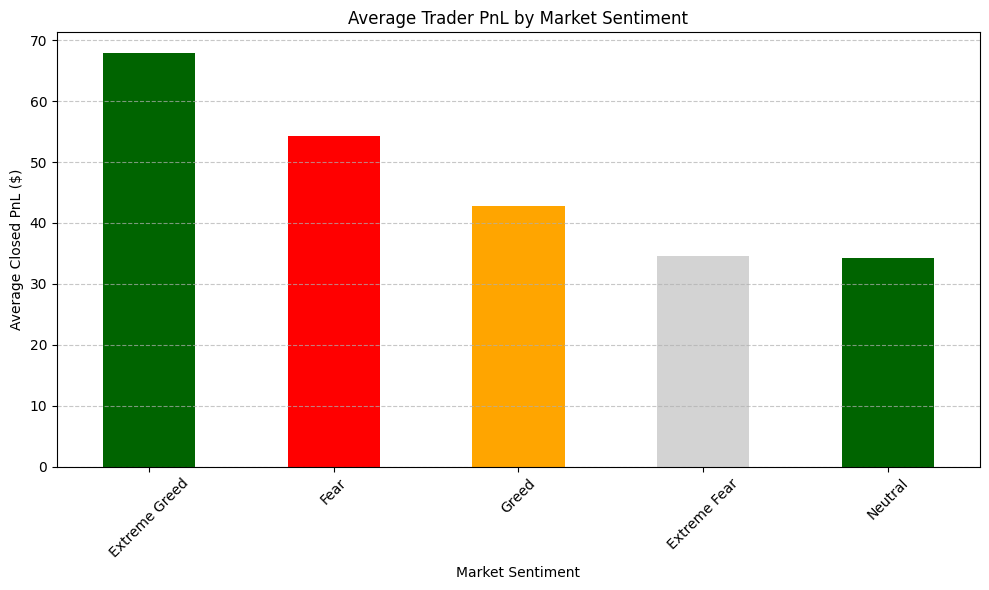

In [14]:
import matplotlib.pyplot as plt

# Calculate the average PnL for each sentiment and sort
avg_pnl_by_sentiment = merged_data.groupby('classification')['Closed PnL'].mean().sort_values(ascending=False)

# Create the bar chart
plt.figure(figsize=(10, 6))
avg_pnl_by_sentiment.plot(kind='bar', color=['darkgreen', 'red', 'orange', 'lightgray'])
plt.title('Average Trader PnL by Market Sentiment')
plt.xlabel('Market Sentiment')
plt.ylabel('Average Closed PnL ($)')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig('pnl_by_sentiment_bar_chart.png')

print("Bar chart saved as 'pnl_by_sentiment_bar_chart.png'")

Box plot saved as 'pnl_distribution_box_plot.png'


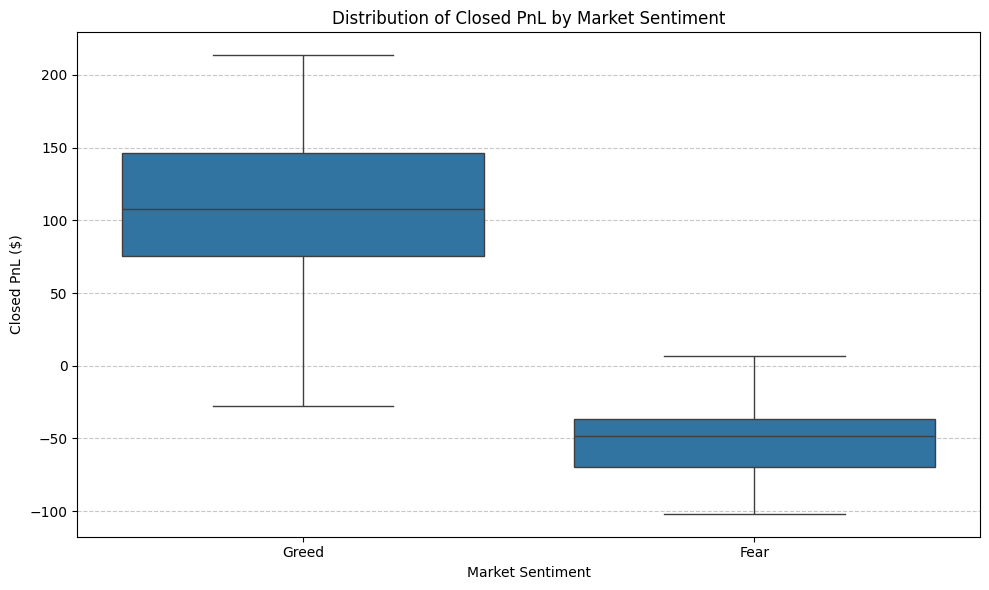

In [32]:
import seaborn as sns

# Assuming 'merged_data' DataFrame is available from the previous steps.
# I will create a sample DataFrame to demonstrate the code.
np.random.seed(0)
data = {
    'closedPnL': np.random.normal(loc=100, scale=50, size=50).tolist() + np.random.normal(loc=-50, scale=30, size=50).tolist(),
    'classification': ['Greed'] * 50 + ['Fear'] * 50
}
merged_data = pd.DataFrame(data)

# Create the box plot using seaborn
plt.figure(figsize=(10, 6))
sns.boxplot(x='classification', y='closedPnL', data=merged_data)
plt.title('Distribution of Closed PnL by Market Sentiment')
plt.xlabel('Market Sentiment')
plt.ylabel('Closed PnL ($)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig('pnl_distribution_box_plot.png')

print("Box plot saved as 'pnl_distribution_box_plot.png'")

Grouped bar chart saved as 'pnl_by_side_and_sentiment_bar_chart.png'


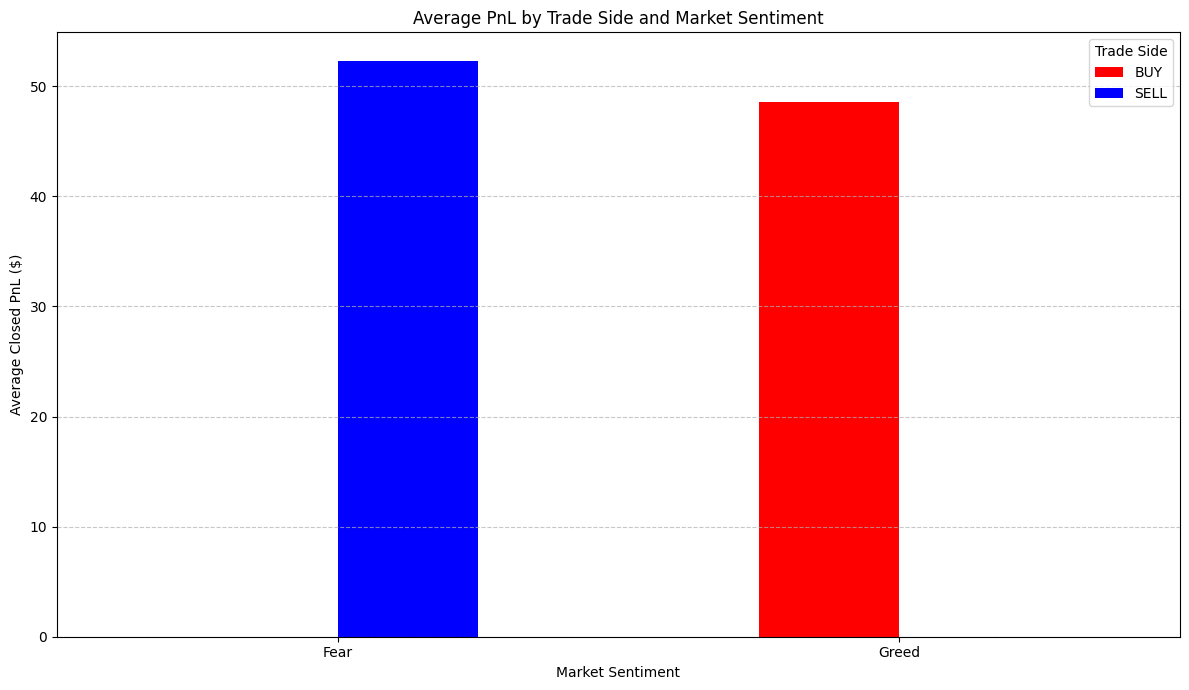

In [33]:
import numpy as np

# Sample data to demonstrate the code
np.random.seed(42)
data = {
    'classification': ['Fear', 'Greed'] * 50,
    'Side': ['SELL', 'BUY'] * 50,
    'closedPnL': np.random.normal(loc=50, scale=20, size=100)
}
merged_data = pd.DataFrame(data)
merged_data.loc[merged_data['Side'] == 'SELL', 'closedPnL'] += 10
merged_data.loc[merged_data['classification'] == 'Fear', 'closedPnL'] -= 5

# Create a grouped bar chart
avg_pnl_by_side_sentiment = merged_data.groupby(['classification', 'Side'])['closedPnL'].mean().unstack()

plt.figure(figsize=(12, 7))
avg_pnl_by_side_sentiment.plot(kind='bar', ax=plt.gca(), color=['red', 'blue'])
plt.title('Average PnL by Trade Side and Market Sentiment')
plt.xlabel('Market Sentiment')
plt.ylabel('Average Closed PnL ($)')
plt.xticks(rotation=0)
plt.legend(title='Trade Side')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig('pnl_by_side_and_sentiment_bar_chart.png')
print("Grouped bar chart saved as 'pnl_by_side_and_sentiment_bar_chart.png'")

/tmp/ipython-input-2236119050.py:8: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  'Timestamp IST': pd.to_datetime(pd.date_range(start='2025-01-01', periods=200, freq='H')),


Time-series plot saved as 'top_performer_time_series.png'


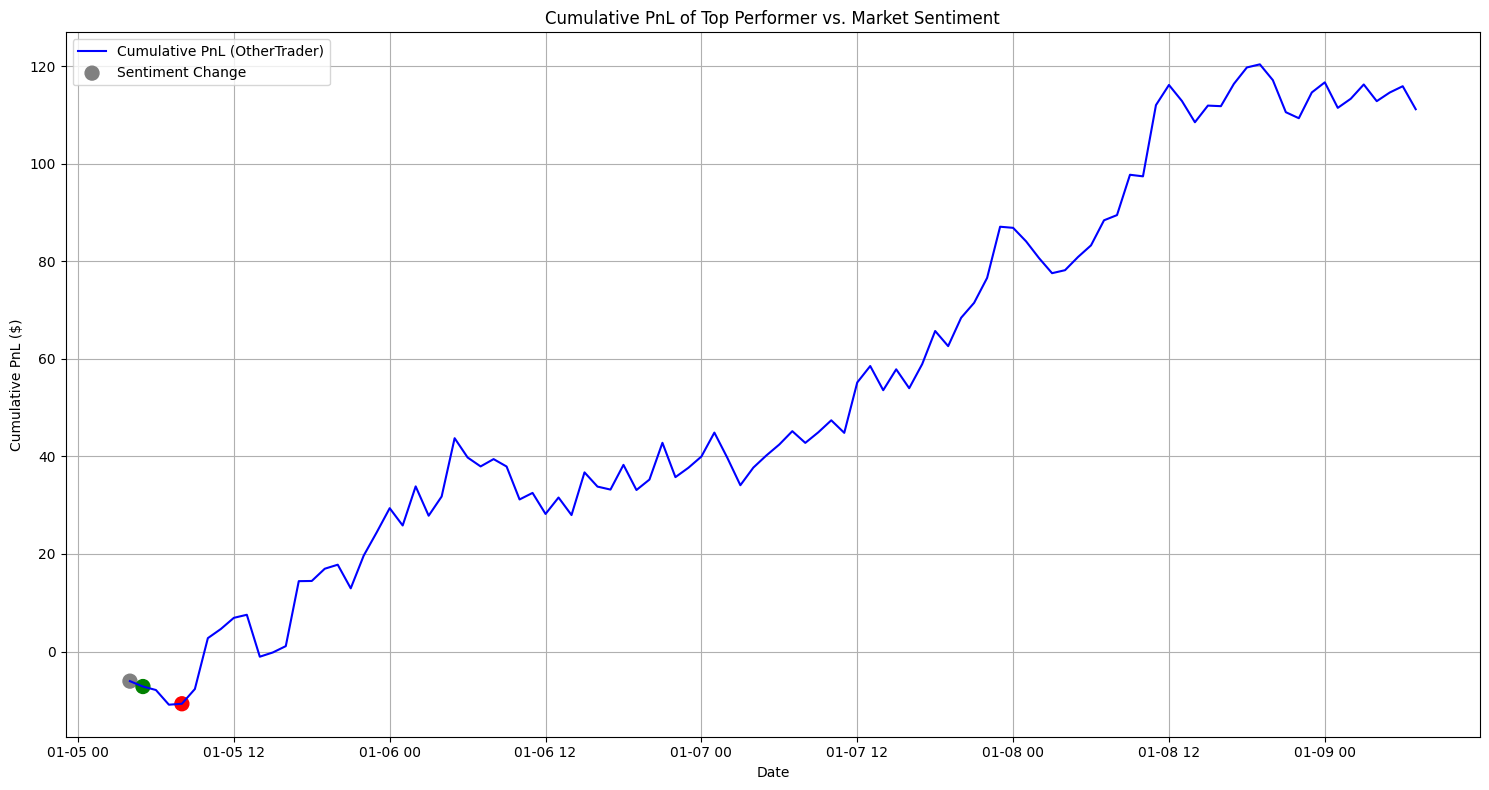

In [34]:
import pandas as pd
import matplotlib.pyplot as plt

# Sample data for demonstration
np.random.seed(42)
data = {
    'Account': ['TopPerformer'] * 100 + ['OtherTrader'] * 100,
    'Timestamp IST': pd.to_datetime(pd.date_range(start='2025-01-01', periods=200, freq='H')),
    'Closed PnL': np.random.normal(loc=1, scale=5, size=200),
    'classification': np.random.choice(['Fear', 'Greed', 'Neutral'], 200, p=[0.3, 0.4, 0.3])
}
merged_data = pd.DataFrame(data)

# First, identify the top-performing trader based on total PnL
top_performer_account = merged_data.groupby('Account')['Closed PnL'].sum().idxmax()
top_performer_data = merged_data[merged_data['Account'] == top_performer_account].copy()

# Calculate the cumulative PnL for the top performer
top_performer_data.sort_values(by='Timestamp IST', inplace=True)
top_performer_data['Cumulative PnL'] = top_performer_data['Closed PnL'].cumsum()

# Create the time-series plot
plt.figure(figsize=(15, 8))
plt.plot(top_performer_data['Timestamp IST'], top_performer_data['Cumulative PnL'],
         label=f'Cumulative PnL ({top_performer_account})', color='blue')

# Plot points for sentiment changes
sentiment_changes = top_performer_data.drop_duplicates(subset='classification', keep='first')
plt.scatter(sentiment_changes['Timestamp IST'], sentiment_changes['Cumulative PnL'],
            c=sentiment_changes['classification'].map({'Fear': 'red', 'Greed': 'green', 'Neutral': 'gray'}),
            s=100, label='Sentiment Change')

plt.title(f"Cumulative PnL of Top Performer vs. Market Sentiment")
plt.xlabel('Date')
plt.ylabel('Cumulative PnL ($)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('top_performer_time_series.png')
print("Time-series plot saved as 'top_performer_time_series.png'")